In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("="*70)
print("🏥 MEDISIGHT - COMPREHENSIVE DATA EXPLORATION")
print("="*70)
print("\nAnalyzing datasets for AI-powered disease prediction...")


🏥 MEDISIGHT - COMPREHENSIVE DATA EXPLORATION

Analyzing datasets for AI-powered disease prediction...


In [2]:
# ==========================================
# 1. DIABETES DATASET EXPLORATION
# ==========================================
print("\n" + "="*70)
print("📊 DATASET 1: PIMA INDIANS DIABETES")
print("="*70)

# Load dataset
diabetes_df = pd.read_csv('../Dataset/Pima_Indians_Diabetes_Dataset/diabetes.csv')

print(f"\n✓ Dataset loaded successfully!")
print(f"  - Rows: {diabetes_df.shape[0]}")
print(f"  - Columns: {diabetes_df.shape[1]}")
print(f"  - Memory usage: {diabetes_df.memory_usage(deep=True).sum() / 1024:.2f} KB")


📊 DATASET 1: PIMA INDIANS DIABETES

✓ Dataset loaded successfully!
  - Rows: 768
  - Columns: 9
  - Memory usage: 54.13 KB


In [3]:
# Display first few rows
print("\n📋 First 5 Records:")
print(diabetes_df.head())

# Data types and info
print("\n📝 Dataset Information:")
print(diabetes_df.info())

# Statistical summary
print("\n📈 Statistical Summary:")
print(diabetes_df.describe())

# Check for missing values
print("\n🔍 Missing Values Check:")
missing = diabetes_df.isnull().sum()
if missing.sum() == 0:
    print("  ✅ No missing values detected!")
else:
    print(missing[missing > 0])

# Check for zero values (medical impossibilities)
print("\n⚠️  Zero Values Analysis (Potential Missing Data):")
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_columns:
    zero_count = (diabetes_df[col] == 0).sum()
    zero_percent = (zero_count / len(diabetes_df)) * 100
    print(f"  - {col:20s}: {zero_count:4d} zeros ({zero_percent:5.2f}%)")


📋 First 5 Records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

📝 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null  

In [4]:
# Target variable distribution
print("\n🎯 Target Variable (Outcome) Distribution:")
outcome_counts = diabetes_df['Outcome'].value_counts()
print(f"  - No Diabetes (0): {outcome_counts[0]} ({outcome_counts[0]/len(diabetes_df)*100:.1f}%)")
print(f"  - Diabetes (1):    {outcome_counts[1]} ({outcome_counts[1]/len(diabetes_df)*100:.1f}%)")
print(f"  - Class balance ratio: {outcome_counts[0]/outcome_counts[1]:.2f}:1")


🎯 Target Variable (Outcome) Distribution:
  - No Diabetes (0): 500 (65.1%)
  - Diabetes (1):    268 (34.9%)
  - Class balance ratio: 1.87:1



📊 Generating visualizations...
  ✓ Saved: diabetes_feature_distributions.png


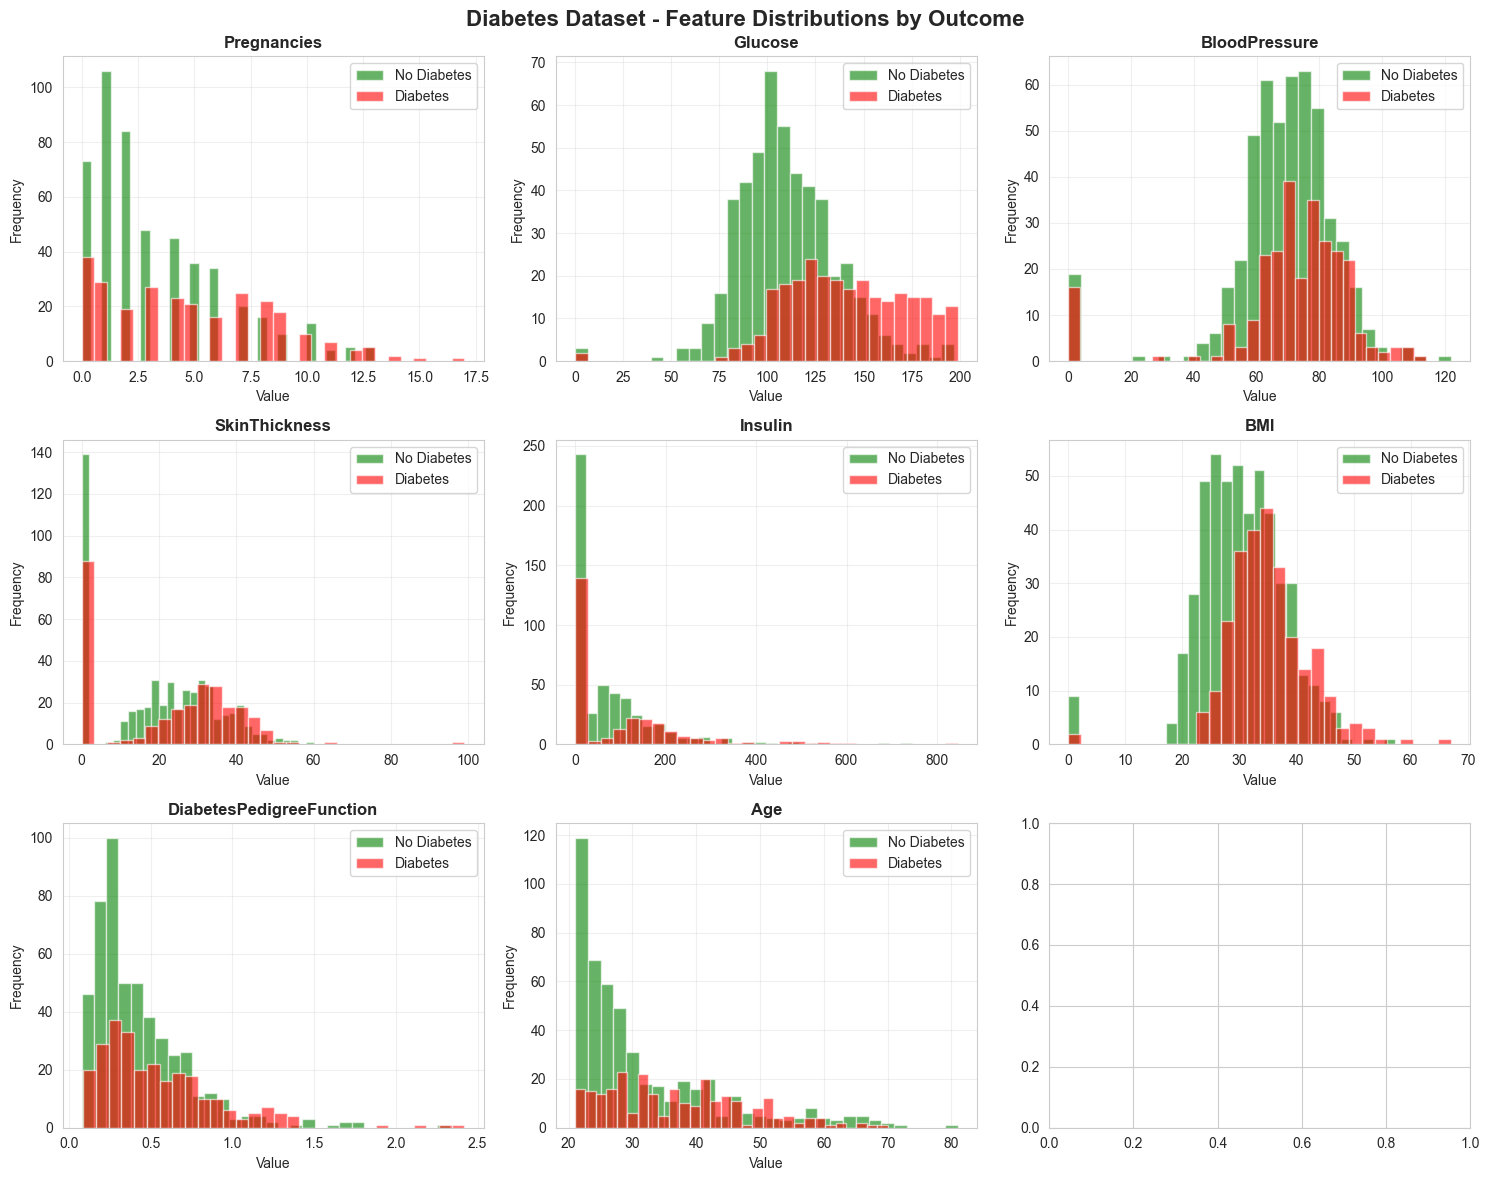

In [5]:
# Visualizations
print("\n📊 Generating visualizations...")

# Figure 1: Feature distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Diabetes Dataset - Feature Distributions by Outcome', fontsize=16, fontweight='bold')

features = diabetes_df.columns[:-1]
for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    
    # Plot distributions for both classes
    diabetes_df[diabetes_df['Outcome'] == 0][feature].hist(
        bins=30, alpha=0.6, label='No Diabetes', ax=axes[row, col], color='green'
    )
    diabetes_df[diabetes_df['Outcome'] == 1][feature].hist(
        bins=30, alpha=0.6, label='Diabetes', ax=axes[row, col], color='red'
    )
    
    axes[row, col].set_title(feature, fontweight='bold')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('diabetes_feature_distributions.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: diabetes_feature_distributions.png")
plt.show()

  ✓ Saved: diabetes_correlation_matrix.png


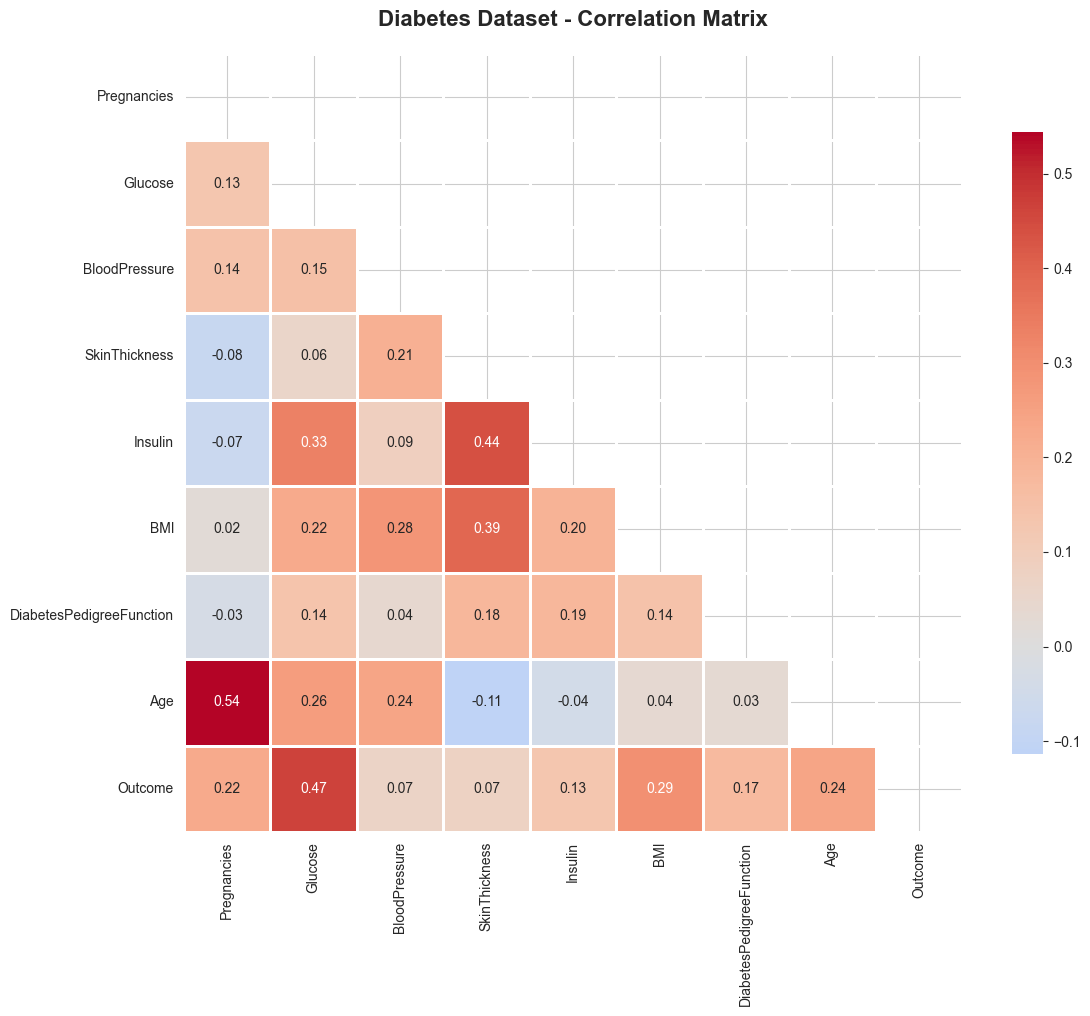

In [6]:
# Figure 2: Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = diabetes_df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Diabetes Dataset - Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('diabetes_correlation_matrix.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: diabetes_correlation_matrix.png")
plt.show()

  ✓ Saved: diabetes_outlier_detection.png


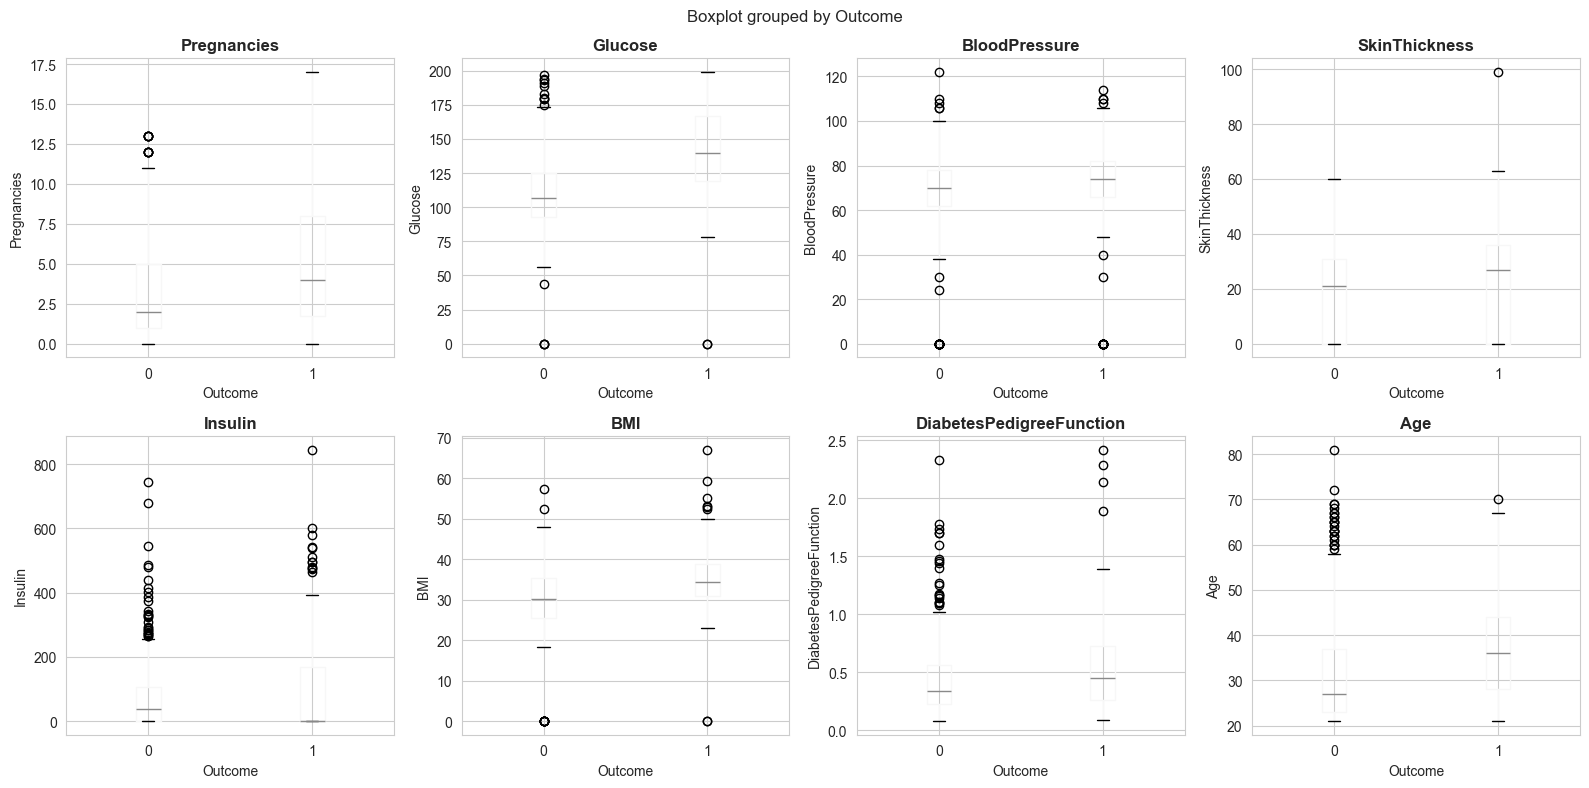

In [7]:
# Figure 3: Box plots for outlier detection
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Diabetes Dataset - Outlier Detection (Box Plots)', fontsize=16, fontweight='bold')

for idx, feature in enumerate(features):
    row = idx // 4
    col = idx % 4
    
    diabetes_df.boxplot(column=feature, by='Outcome', ax=axes[row, col])
    axes[row, col].set_title(feature, fontweight='bold')
    axes[row, col].set_xlabel('Outcome')
    axes[row, col].set_ylabel(feature)

plt.tight_layout()
plt.savefig('diabetes_outlier_detection.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: diabetes_outlier_detection.png")
plt.show()

In [8]:
# Correlation with target
print("\n🔗 Feature Correlation with Target (Outcome):")
target_correlation = diabetes_df.corr()['Outcome'].sort_values(ascending=False)
print(target_correlation)

print("\n✅ Diabetes dataset exploration complete!")


🔗 Feature Correlation with Target (Outcome):
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

✅ Diabetes dataset exploration complete!


In [9]:
# ==========================================
# 2. HEART DISEASE DATASET EXPLORATION
# ==========================================
print("\n" + "="*70)
print("📊 DATASET 2: CLEVELAND HEART DISEASE")
print("="*70)

# Load dataset
heart_df = pd.read_csv('../Dataset/Cleveland_Heart_Disease/heart.csv')

print(f"\n✓ Dataset loaded successfully!")
print(f"  - Rows: {heart_df.shape[0]}")
print(f"  - Columns: {heart_df.shape[1]}")


📊 DATASET 2: CLEVELAND HEART DISEASE

✓ Dataset loaded successfully!
  - Rows: 303
  - Columns: 14


In [10]:
# Display first few rows
print("\n📋 First 5 Records:")
print(heart_df.head())

# Data types
print("\n📝 Dataset Information:")
print(heart_df.info())

# Statistical summary
print("\n📈 Statistical Summary:")
print(heart_df.describe())

# Missing values
print("\n🔍 Missing Values Check:")
missing_heart = heart_df.isnull().sum()
if missing_heart.sum() == 0:
    print("  ✅ No missing values detected!")
else:
    print(missing_heart[missing_heart > 0])


📋 First 5 Records:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

📝 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64 

In [11]:
# Target distribution
print("\n🎯 Target Variable Distribution:")
target_counts = heart_df['target'].value_counts()
print(f"  - No Heart Disease (0): {target_counts[0]} ({target_counts[0]/len(heart_df)*100:.1f}%)")
print(f"  - Heart Disease (1):    {target_counts[1]} ({target_counts[1]/len(heart_df)*100:.1f}%)")

# Feature meanings
print("\n📚 Feature Descriptions:")
feature_descriptions = {
    'age': 'Age in years',
    'sex': 'Sex (1 = male; 0 = female)',
    'cp': 'Chest pain type (0-3)',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol': 'Serum cholesterol (mg/dl)',
    'fbs': 'Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)',
    'restecg': 'Resting ECG results (0-2)',
    'thalach': 'Maximum heart rate achieved',
    'exang': 'Exercise induced angina (1 = yes; 0 = no)',
    'oldpeak': 'ST depression induced by exercise',
    'slope': 'Slope of peak exercise ST segment',
    'ca': 'Number of major vessels colored by fluoroscopy (0-3)',
    'thal': 'Thalassemia (1-3)',
    'target': 'Heart disease diagnosis (1 = disease; 0 = no disease)'
}

for feature, description in feature_descriptions.items():
    print(f"  - {feature:12s}: {description}")


🎯 Target Variable Distribution:
  - No Heart Disease (0): 138 (45.5%)
  - Heart Disease (1):    165 (54.5%)

📚 Feature Descriptions:
  - age         : Age in years
  - sex         : Sex (1 = male; 0 = female)
  - cp          : Chest pain type (0-3)
  - trestbps    : Resting blood pressure (mm Hg)
  - chol        : Serum cholesterol (mg/dl)
  - fbs         : Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
  - restecg     : Resting ECG results (0-2)
  - thalach     : Maximum heart rate achieved
  - exang       : Exercise induced angina (1 = yes; 0 = no)
  - oldpeak     : ST depression induced by exercise
  - slope       : Slope of peak exercise ST segment
  - ca          : Number of major vessels colored by fluoroscopy (0-3)
  - thal        : Thalassemia (1-3)
  - target      : Heart disease diagnosis (1 = disease; 0 = no disease)



📊 Generating visualizations...
  ✓ Saved: heart_disease_feature_distributions.png


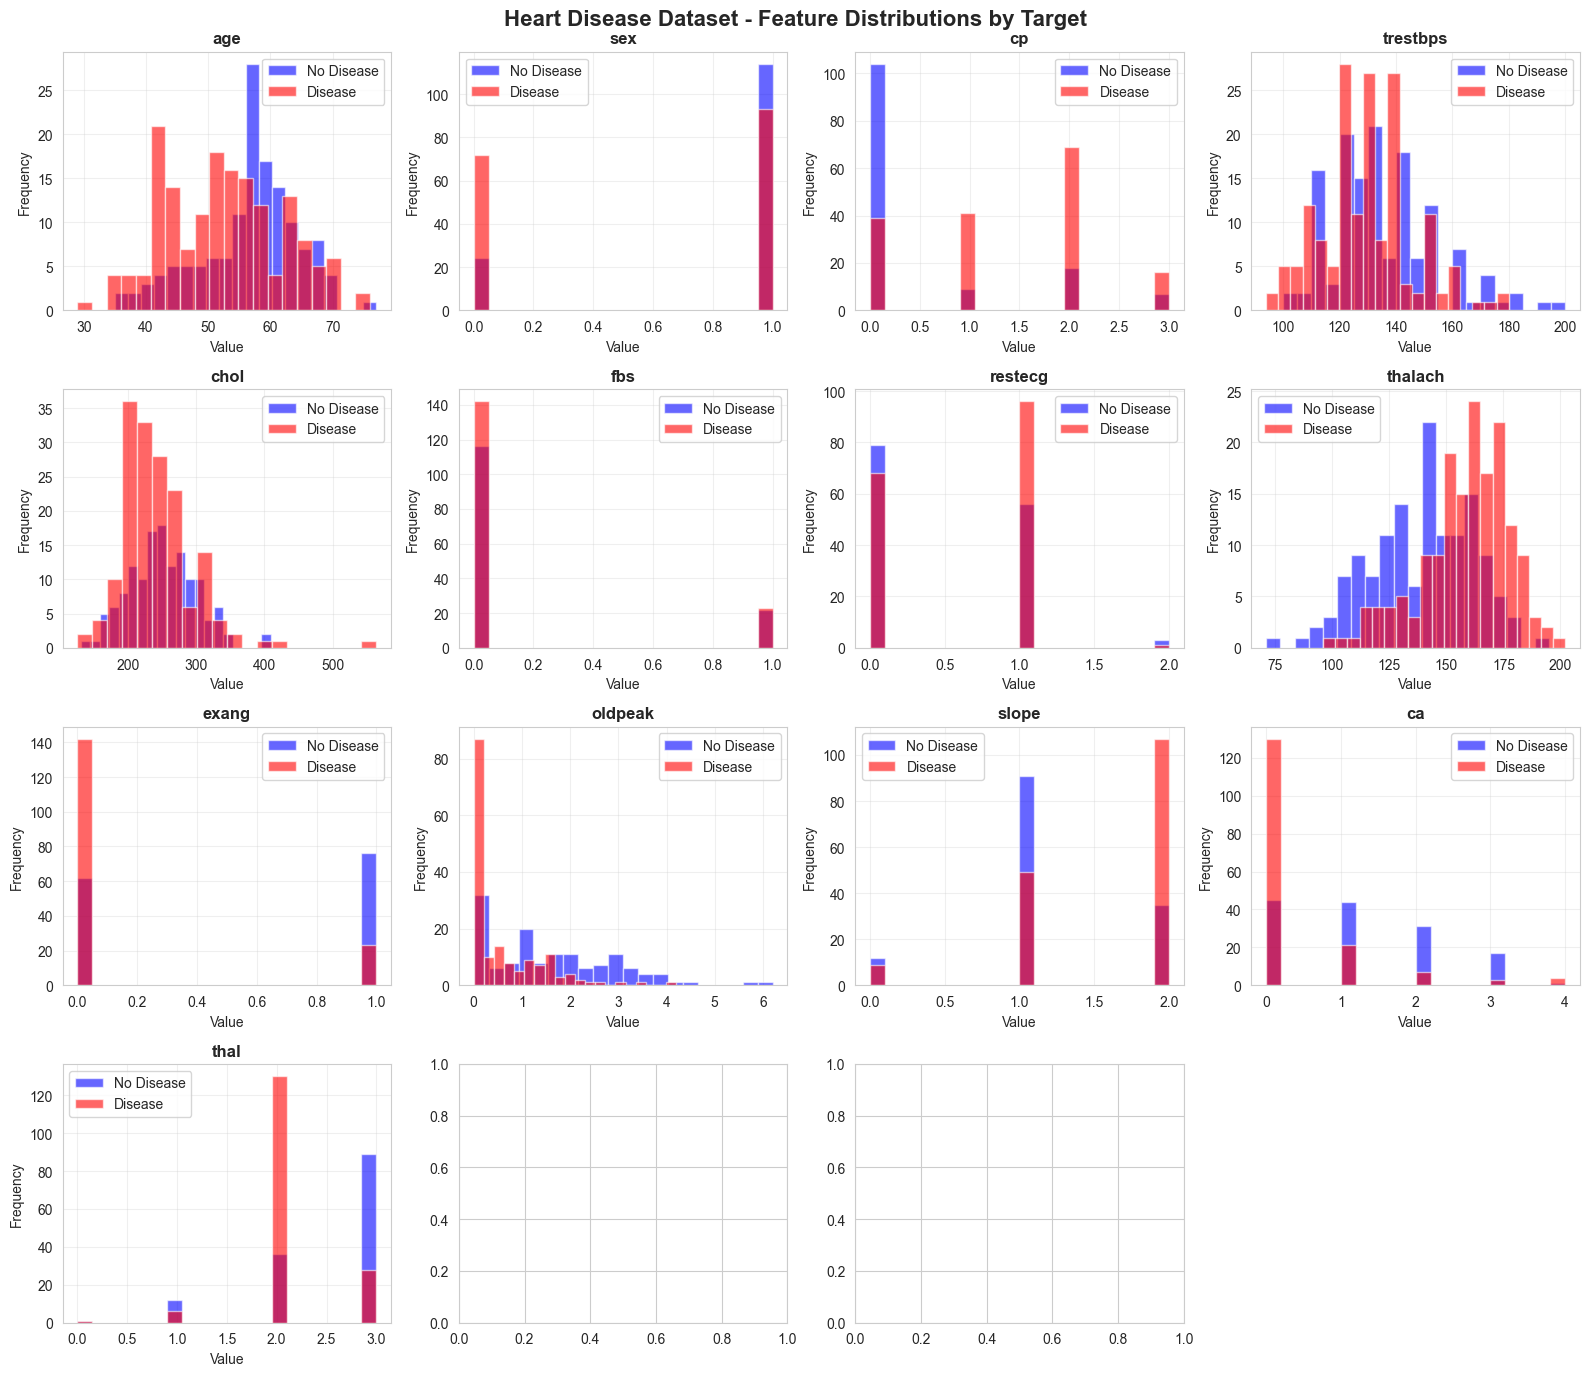

In [12]:
# Visualizations for heart disease
print("\n📊 Generating visualizations...")

# Figure 4: Heart disease feature distributions
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
fig.suptitle('Heart Disease Dataset - Feature Distributions by Target', fontsize=16, fontweight='bold')

heart_features = heart_df.columns[:-1]
for idx, feature in enumerate(heart_features):
    if idx < 13:
        row = idx // 4
        col = idx % 4
        
        heart_df[heart_df['target'] == 0][feature].hist(
            bins=20, alpha=0.6, label='No Disease', ax=axes[row, col], color='blue'
        )
        heart_df[heart_df['target'] == 1][feature].hist(
            bins=20, alpha=0.6, label='Disease', ax=axes[row, col], color='red'
        )
        
        axes[row, col].set_title(feature, fontweight='bold')
        axes[row, col].set_xlabel('Value')
        axes[row, col].set_ylabel('Frequency')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)

# Hide unused subplot
axes[3, 3].axis('off')

plt.tight_layout()
plt.savefig('heart_disease_feature_distributions.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: heart_disease_feature_distributions.png")
plt.show()

  ✓ Saved: heart_disease_correlation_matrix.png


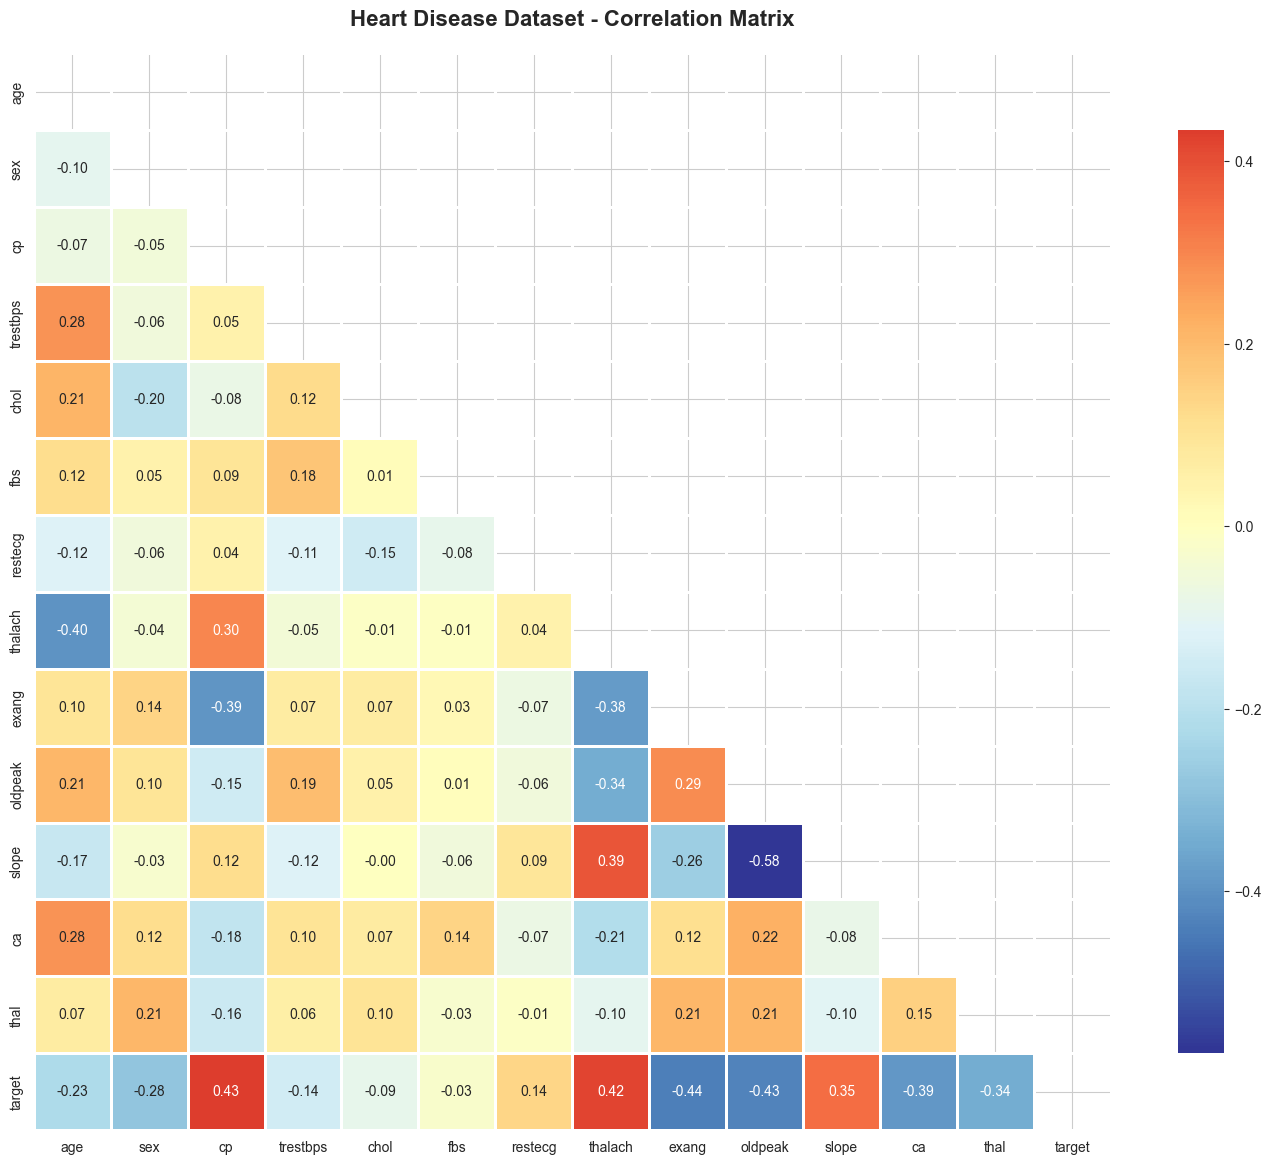

In [13]:
# Figure 5: Heart disease correlation heatmap
plt.figure(figsize=(14, 12))
heart_correlation = heart_df.corr()
mask_heart = np.triu(np.ones_like(heart_correlation, dtype=bool))
sns.heatmap(heart_correlation, mask=mask_heart, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Heart Disease Dataset - Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('heart_disease_correlation_matrix.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: heart_disease_correlation_matrix.png")
plt.show()


🔗 Feature Correlation with Target:
target      1.000000
cp          0.433798
thalach     0.421741
slope       0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
sex        -0.280937
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
Name: target, dtype: float64

📊 Categorical Feature Analysis:
  ✓ Saved: heart_disease_categorical_analysis.png


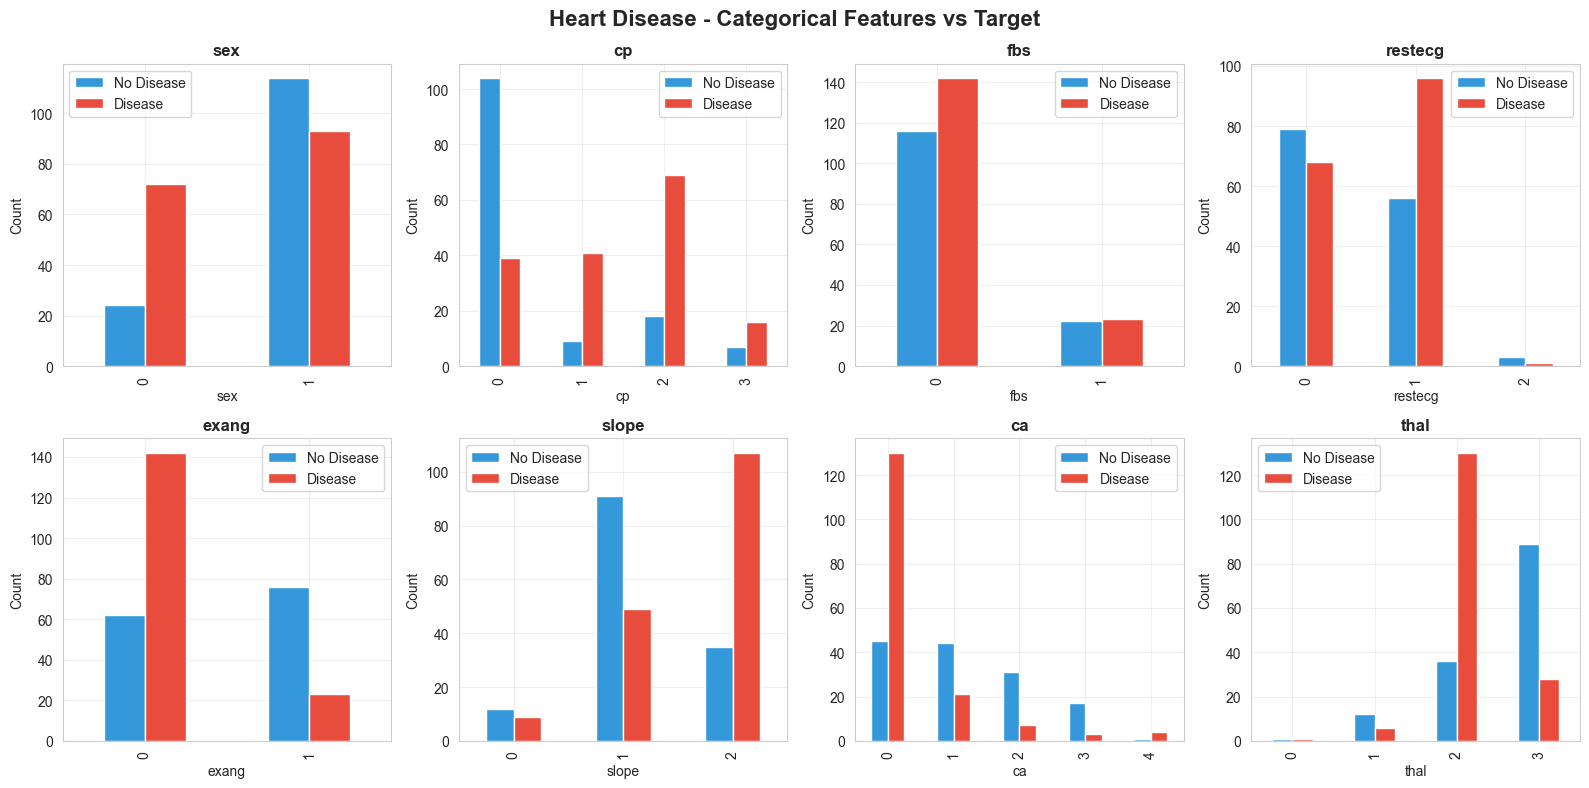


✅ Heart disease dataset exploration complete!


In [14]:
# Correlation with target
print("\n🔗 Feature Correlation with Target:")
heart_target_corr = heart_df.corr()['target'].sort_values(ascending=False)
print(heart_target_corr)

# Categorical feature analysis
print("\n📊 Categorical Feature Analysis:")
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Heart Disease - Categorical Features vs Target', fontsize=16, fontweight='bold')

for idx, feature in enumerate(categorical_features):
    row = idx // 4
    col = idx % 4
    
    pd.crosstab(heart_df[feature], heart_df['target']).plot(
        kind='bar', ax=axes[row, col], color=['#3498db', '#e74c3c']
    )
    axes[row, col].set_title(feature, fontweight='bold')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Count')
    axes[row, col].legend(['No Disease', 'Disease'])
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('heart_disease_categorical_analysis.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: heart_disease_categorical_analysis.png")
plt.show()

print("\n✅ Heart disease dataset exploration complete!")

In [16]:
# ==========================================
# 3. CKD DATASET EXPLORATION
# ==========================================
print("\n" + "="*70)
print("📊 DATASET 3: CHRONIC KIDNEY DISEASE (CKD)")
print("="*70)

try:
    ckd_df = pd.read_csv('../Dataset/chronic_kidney_disease/kidney_disease.csv')
    
    print(f"\n✓ Dataset loaded successfully!")
    print(f"  - Rows: {ckd_df.shape[0]}")
    print(f"  - Columns: {ckd_df.shape[1]}")
    
    print("\n📋 First 5 Records:")
    print(ckd_df.head())
    
    print("\n📝 Dataset Information:")
    print(ckd_df.info())
    
    print("\n🔍 Missing Values:")
    ckd_missing = ckd_df.isnull().sum()
    print(ckd_missing[ckd_missing > 0])
    
    print("\n✅ CKD dataset exploration complete!")
    
except FileNotFoundError:
    print("  ⚠️  CKD dataset file not found. Skipping...")


📊 DATASET 3: CHRONIC KIDNEY DISEASE (CKD)

✓ Dataset loaded successfully!
  - Rows: 400
  - Columns: 26

📋 First 5 Records:
   id   age    bp     sg   al   su     rbc        pc         pcc          ba  \
0   0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2   2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3   3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4   4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

   ...  pcv    wc   rc  htn   dm  cad appet   pe  ane classification  
0  ...   44  7800  5.2  yes  yes   no  good   no   no            ckd  
1  ...   38  6000  NaN   no   no   no  good   no   no            ckd  
2  ...   31  7500  NaN   no  yes   no  poor   no  yes            ckd  
3  ...   32  6700  3.9  yes   no   no  poor  yes  yes            ckd  
4  ...   35  7300  4.6   no   no   no  

In [17]:
# ==========================================
# 4. STROKE DATASET EXPLORATION
# ==========================================
print("\n" + "="*70)
print("📊 DATASET 4: STROKE PREDICTION")
print("="*70)

try:
    stroke_df = pd.read_csv('../Dataset/Stroke_Prediction_Dataset/healthcare-dataset-stroke-data.csv')
    
    print(f"\n✓ Dataset loaded successfully!")
    print(f"  - Rows: {stroke_df.shape[0]}")
    print(f"  - Columns: {stroke_df.shape[1]}")
    
    print("\n📋 First 5 Records:")
    print(stroke_df.head())
    
    print("\n🎯 Target Distribution:")
    stroke_counts = stroke_df['stroke'].value_counts()
    print(f"  - No Stroke (0): {stroke_counts[0]} ({stroke_counts[0]/len(stroke_df)*100:.1f}%)")
    print(f"  - Stroke (1):    {stroke_counts[1]} ({stroke_counts[1]/len(stroke_df)*100:.1f}%)")
    print(f"  ⚠️  Class imbalance: {stroke_counts[0]/stroke_counts[1]:.1f}:1")
    
    print("\n✅ Stroke dataset exploration complete!")
    
except FileNotFoundError:
    print("  ⚠️  Stroke dataset file not found. Skipping...")


📊 DATASET 4: STROKE PREDICTION

✓ Dataset loaded successfully!
  - Rows: 5110
  - Columns: 12

📋 First 5 Records:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0

In [18]:
# ==========================================
# SUMMARY & RECOMMENDATIONS
# ==========================================
print("\n" + "="*70)
print("📋 EXPLORATION SUMMARY & RECOMMENDATIONS")
print("="*70)

print("\n🎯 RECOMMENDED MODELS FOR TRAINING:")
print("  1. ✅ DIABETES (Pima Indians)")
print("     - Clean dataset, 768 samples")
print("     - 8 features, binary classification")
print("     - Expected accuracy: 75-85%")
print("     - BEST FOR: Starting point, clear SHAP explanations")
print()
print("  2. ✅ HEART DISEASE (Cleveland)")
print("     - Clean dataset, 303 samples")
print("     - 13 features, binary classification")
print("     - Expected accuracy: 80-90%")
print("     - BEST FOR: Diverse features, high accuracy")
print()
print("  3. ⚠️  STROKE (Large but imbalanced)")
print("     - 5110 samples but highly imbalanced")
print("     - Requires special handling (SMOTE, class weights)")
print("     - Optional: Advanced challenge")
print()
print("  4. ⚠️  CKD (Needs cleaning)")
print("     - Many missing values")
print("     - Requires preprocessing")
print("     - Optional: Data cleaning practice")

print("\n💡 NEXT STEPS:")
print("  1. Train Diabetes model (Primary)")
print("  2. Train Heart Disease model (Secondary)")
print("  3. Build FastAPI service with both models")
print("  4. Create Django backend")
print("  5. Build Next.js frontend")

print("\n🚀 DATA QUALITY ASSESSMENT:")
print("  ✅ Diabetes: Ready for training")
print("  ✅ Heart Disease: Ready for training")
print("  ⚠️  Stroke: Needs class balancing")
print("  ⚠️  CKD: Needs missing value handling")

print("\n" + "="*70)
print("🎉 DATA EXPLORATION COMPLETE!")
print("="*70)
print("\n📁 Generated files:")
print("  - diabetes_feature_distributions.png")
print("  - diabetes_correlation_matrix.png")
print("  - diabetes_outlier_detection.png")
print("  - heart_disease_feature_distributions.png")
print("  - heart_disease_correlation_matrix.png")
print("  - heart_disease_categorical_analysis.png")
print("\nReady to proceed with model training! 🚀")


📋 EXPLORATION SUMMARY & RECOMMENDATIONS

🎯 RECOMMENDED MODELS FOR TRAINING:
  1. ✅ DIABETES (Pima Indians)
     - Clean dataset, 768 samples
     - 8 features, binary classification
     - Expected accuracy: 75-85%
     - BEST FOR: Starting point, clear SHAP explanations

  2. ✅ HEART DISEASE (Cleveland)
     - Clean dataset, 303 samples
     - 13 features, binary classification
     - Expected accuracy: 80-90%
     - BEST FOR: Diverse features, high accuracy

  3. ⚠️  STROKE (Large but imbalanced)
     - 5110 samples but highly imbalanced
     - Requires special handling (SMOTE, class weights)
     - Optional: Advanced challenge

  4. ⚠️  CKD (Needs cleaning)
     - Many missing values
     - Requires preprocessing
     - Optional: Data cleaning practice

💡 NEXT STEPS:
  1. Train Diabetes model (Primary)
  2. Train Heart Disease model (Secondary)
  3. Build FastAPI service with both models
  4. Create Django backend
  5. Build Next.js frontend

🚀 DATA QUALITY ASSESSMENT:
  ✅ Diabetes